# Vietnamese Documents Classification - NLP Project

# Connect Google Drive

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Installations

In [6]:
!pip install pyvi
!pip install torch
!pip install gensim
!pip install transformers

# Import Libraries

In [4]:
import os
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# NLP Libraries
from pyvi import ViTokenizer
import gensim
from gensim.utils import simple_preprocess
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from transformers import AutoTokenizer, AutoModel

# Machine Learning
from sklearn.preprocessing import LabelEncoder

# Deep Learning (TensorFlow/Keras)
import torch
import tensorflow as tf
from keras.models import Sequential, load_model
from keras.layers import LSTM, Dense, Embedding
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# Build Models

## Deep Learning

In [7]:
def train_nn_model(X_train, X_test, y_train, y_test, epochs=30, embedding_dim=300):
    num_classes = len(np.unique(y_train))
    y_train_cat = to_categorical(y_train, num_classes=num_classes)
    y_test_cat = to_categorical(y_test, num_classes=num_classes)

    model = Sequential()
    model.add(Input(shape=(embedding_dim,)))

    # Dense layer 1
    model.add(Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.005)))
    model.add(Dropout(0.5))
    model.add(BatchNormalization())

    # Dense layer 2
    model.add(Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.005)))
    model.add(Dropout(0.4))
    model.add(BatchNormalization())

    # Dense layer 3
    model.add(Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.005)))
    model.add(Dropout(0.4))
    model.add(BatchNormalization())

    # Dense layer 4
    model.add(Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.005)))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    model.summary()

    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # Train the model with early stopping
    history = model.fit(X_train, y_train_cat, epochs=epochs, batch_size=32,
                        validation_data=(X_test, y_test_cat), verbose=1,
                        callbacks=[early_stopping])

    loss, accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
    print(f"\nAccuracy: {accuracy:.4f}")

    return model, history

def plot_history(history):
  epochs = range(1, len(history.history['loss']) + 1)

  # loss
  plt.plot(epochs, history.history['loss'], 'bo-', label='Train Loss')
  plt.plot(epochs, history.history['val_loss'], 'ro-', label='Validation Loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.show()

  # accuracy
  plt.plot(epochs, history.history['accuracy'], 'bo-', label='Train Accuracy')
  plt.plot(epochs, history.history['val_accuracy'], 'ro-', label='Validation Accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.show()

# Dataset paths

In [11]:
train_path = '/content/drive/MyDrive/NLP/Doc2Vec/Dataset/train.csv'
test_path = '/content/drive/MyDrive/NLP/Doc2Vec/Dataset/test.csv'
stopwords_path = '/content/drive/MyDrive/NLP/stopwords-vi.txt'

# Preprocess dataset

In [9]:
def load_stopwords(file_path):
  with open(file_path, 'r', encoding='utf-8-sig') as f:
    return {line.strip() for line in f if line.strip()}

def preprocess(text, stopwords, pre_tokenized=True):
  if pre_tokenized:
    tokenized_text = ViTokenizer.tokenize(text)
  else:
    tokenized_text = text

  tokens = simple_preprocess(tokenized_text)
  tokens = [token for token in tokens if token not in stopwords]
  return " ".join(tokens)

In [12]:
# load Vietnamese stopwords
stopwords = load_stopwords(stopwords_path)

# preprocess train dataset and save as 'processed_train.csv'
train_df = pd.read_csv(train_path)
train_df['text'] = train_df['text'].apply(lambda x: preprocess(x, stopwords))
train_df.to_csv('processed_train.csv')

# preprocess test dataset and save as 'processed_test.csv'
test_df = pd.read_csv(test_path)
test_df['text'] = test_df['text'].apply(lambda x: preprocess(x, stopwords))
test_df.to_csv('processed_test.csv')

In [18]:
drive_save_dir = '/content/drive/MyDrive/NLP/Doc2Vec/Dataset/'

# Save the preprocessed train and test datasets
train_df.to_csv(os.path.join(drive_save_dir, 'processed_train.csv'), index=False)
test_df.to_csv(os.path.join(drive_save_dir, 'processed_test.csv'), index=False)

print(f"Processed datasets saved to: {drive_save_dir}")

Processed datasets saved to: /content/drive/MyDrive/NLP/Doc2Vec/Dataset/


In [13]:
train_df.shape, test_df.shape

((33759, 2), (50373, 2))

In [14]:
train_df['text'].iloc[10]

'phòng học bộ_môn xóa_bỏ tình_trạng dạy chay học chạy học_sinh cơ_hội thực_hành phòng học bộ_môn phòng học truyền_thống bảng_đen phấn trắng bàn ghế học_sinh thụ_động giờ học giáo_viên bộ_môn di_chuyển thời khóa biểu giáo_viên tự mang thiết_bị dạy_học lớp nội_dung giảng cần_thiết_bị cách dạy phù_hợp kiểu dạy chay học chay tất_cả vấn_đề khắc_phục phòng học bộ_môn lê_quán tần vụ_trưởng vụ giáo_dục trung_học khẳng_định xóa_sổ phòng học truyền_thống giáo_dục đào_tạo hoàn_thiện sửa_đổi bổ_sung quy_chế phòng học bộ_môn phbm trường trung_học bao_gồm trường thcs thpt đạt chuẩn quốc_gia cụ_thể trường đạt chuẩn xây_dựng phbm dành môn_học như_vậy tiết học thay_vì ngồi học lý_thuyết đơn_thuần học_sinh chuyển sang học phòng tài_liệu thiết_bị đặc_thù giúp học_sinh thực_hiện hoạt_động thực_hành môn_học lê hoàng_hảo giám_đốc công_ty thiết_bị giáo_dục phbm xu_hướng tất_yếu nước giáo_dục tiên_tiến học_sinh học lý_thuyết thực_hành phbm phòng học kiểu thiết_bị bảo_quản tốt di_chuyển tiết_kiệm kinh_tế thiết

Get texts, labels

In [15]:
X_train = train_df['text']
y_train = train_df['label']

X_test = test_df['text']
y_test = test_df['label']

Distribution chart of train labels

<Axes: xlabel='label'>

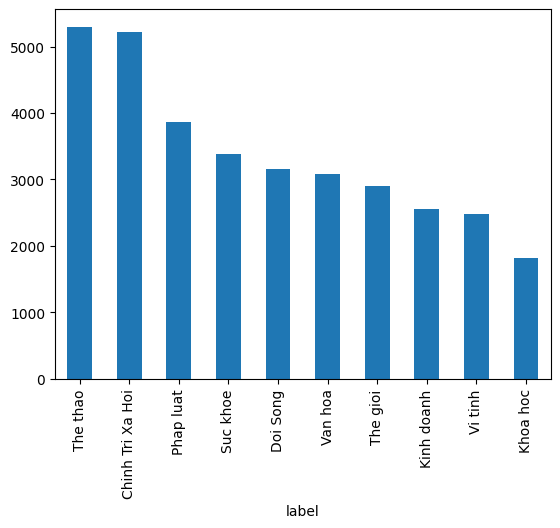

In [16]:
y_train.value_counts().plot(kind='bar')

In [17]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test)

# Doc2Vec

### Train Doc2Vec with train dataset

In [22]:
def train_doc2vec_model(texts, vector_size=300, window=5, min_count=2, epochs=5):
  # convert each text into a TaggedDocument required by Doc2Vec
  documents = [TaggedDocument(words=doc.split(), tags=[str(i)]) for i, doc in enumerate(texts)]

  # initialize Doc2Vec model with 1 epoch for initial training
  model = Doc2Vec(vector_size=vector_size, window=window, min_count=min_count, workers=4, epochs=1, compute_loss=True)
  model.build_vocab(documents)
  model.train(documents, total_examples=model.corpus_count, epochs=model.epochs)

  # train the model for the specified number of epochs, using range() to fix the iteration error
  for epoch in range(epochs):
    model.train(documents, total_examples=model.corpus_count, epochs= 1)
    print(f"Epoch {epoch+1} / {epochs}")
  model.save("doc2vec.model")
  return model

In [23]:
doc2vec_model = train_doc2vec_model(X_train)
# doc2vec_model = Doc2Vec.load('doc2vec.model')

Epoch 1 / 5


Epoch 2 / 5


Epoch 3 / 5


Epoch 4 / 5
Epoch 5 / 5


In [24]:
import shutil

model_save_dir = '/content/drive/MyDrive/NLP/Doc2Vec/Models/'

# List of files generated by Doc2Vec save
model_files = ['doc2vec.model', 'doc2vec.model.trainables.syn1neg.npy', 'doc2vec.model.wv.vectors.npy']

for file_name in model_files:
    if os.path.exists(file_name):
        shutil.copy(file_name, os.path.join(model_save_dir, file_name))
        print(f"Saved {file_name} to {model_save_dir}")
    else:
        # Some versions might not have all .npy files depending on training params
        pass

print("Model backup to Drive complete.")

Saved doc2vec.model to /content/drive/MyDrive/NLP/Doc2Vec/Models/
Saved doc2vec.model.wv.vectors.npy to /content/drive/MyDrive/NLP/Doc2Vec/Models/
Model backup to Drive complete.


### Infer Vectors

In [27]:
import numpy as np

def get_doc2vec_embeddings(doc2vec_model, texts):
  embeddings = []
  for text in tqdm(texts, desc="Inferring Doc2Vec Embeddings"):
    emb = doc2vec_model.infer_vector(text.split())
    embeddings.append(emb)
  return np.array(embeddings)

In [28]:
X_train_doc2vec = get_doc2vec_embeddings(doc2vec_model, X_train)
np.save("/content/drive/MyDrive/NLP/Doc2Vec/Dataset/train_doc2vec_emb.npy", X_train_doc2vec)
print("X_train_doc2vec saved to Drive.")

X_test_doc2vec = get_doc2vec_embeddings(doc2vec_model, X_test)
np.save("/content/drive/MyDrive/NLP/Doc2Vec/Dataset/test_doc2vec_emb.npy", X_test_doc2vec)
print("X_test_doc2vec saved to Drive.")

Inferring Doc2Vec Embeddings: 100%|██████████| 33759/33759 [00:45<00:00, 744.29it/s]


X_train_doc2vec saved to Drive.


Inferring Doc2Vec Embeddings: 100%|██████████| 50373/50373 [01:08<00:00, 732.43it/s]


X_test_doc2vec saved to Drive.


### Train DL Model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       154,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 330,826 (1.26 MB)

 Trainable params: 329,034 (1.26 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/30
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 25s 19ms/step - accuracy: 0.2263 - loss: 6.8524 - val_accuracy: 0.6198 - val_loss: 5.7503
Epoch 2/30
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.4496 - loss: 5.5602 - val_accuracy: 0.7350 - val_loss: 4.6339
Epoch 3/30
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.5849 - loss: 4.5946 - val_accuracy: 0.7726 - val_loss: 3.8178
Epoch 4/30
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.6571 - loss: 3.8214 - val_accuracy: 0.7989 - val_loss: 3.1627
Epoch 5/30
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.6984 - loss: 3.1959 - val_accuracy: 0.8099 - val_loss: 2.6393
Epoch 6/30
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.7247 - loss: 2.6958 - val_accuracy: 0.8183 - val_loss: 2.2186
Epoch 7/30
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/step - accuracy: 0.7457 - loss: 2.2876 - val_accuracy: 0.8268 - val_loss: 1.8790
Epoch 8/30
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.7543 -

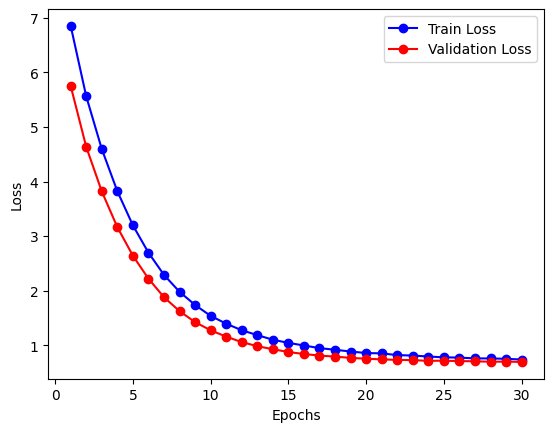

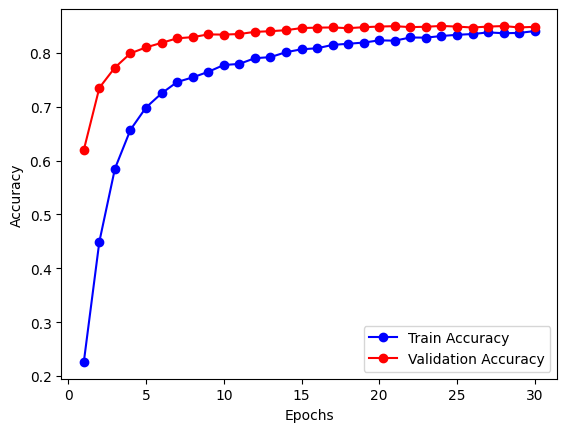

In [29]:
doc2vec_nn_model, doc2vec_history = train_nn_model(X_train_doc2vec, X_test_doc2vec, y_train, y_test)
plot_history(doc2vec_history)

In [31]:
model_save_path = os.path.join(model_save_dir, 'doc2vec_nn_model.keras')

# Save the model in the native Keras format
doc2vec_nn_model.save(model_save_path)

print(f"Neural Network model saved to: {model_save_path}")

Neural Network model saved to: /content/drive/MyDrive/NLP/Doc2Vec/Models/doc2vec_nn_model.keras


### Example

In [38]:
def classify_text(text, stopwords, doc2vec, model):
  text = preprocess(text, stopwords)
  vector = doc2vec.infer_vector(text.split())
  vector = np.array(vector).reshape(1, -1)

  pred = model.predict(vector)
  pred_idx = np.argmax(pred, axis=1)[0]

  labels = ['Chính trị xã hội', 'Đời sống', 'Khoa học', 'Kinh doanh', 'Pháp luật', 'Sức khoẻ', 'Thế giới', 'Thể thao', 'Văn hoá', 'Vi tính']
  pred_label = labels[pred_idx]
  print("Predicted class index:", pred_idx)
  print("Predicted class label:", pred_label)

In [44]:
text = """Lãnh đạo Quốc hội và các Ủy ban nhiệm kỳ 2026-2031
Sau khi kiện toàn, Thường vụ Quốc hội khóa 16 nhiệm kỳ 2026-2031 có 18 thành viên, gồm Chủ tịch Quốc hội, 6 Phó chủ tịch và 11 Chủ nhiệm, Phó chủ nhiệm thường trực các Ủy ban."""
classify_text(text, stopwords, doc2vec_model, doc2vec_nn_model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted class index: 0
Predicted class label: Chính trị xã hội
